
Loading Dataset...
Dataset Shape: (100, 8)

Class Distribution:
Class
0    97
1     3
Name: count, dtype: int64


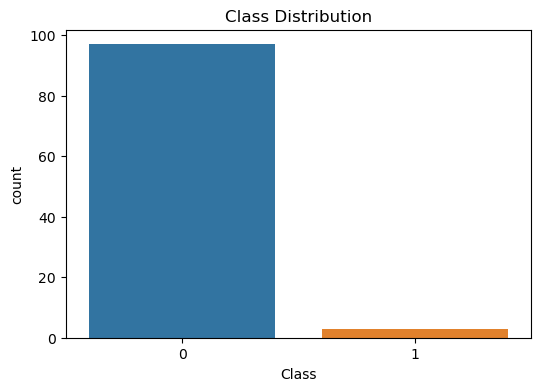


Fraud Percentage: 3.0000%


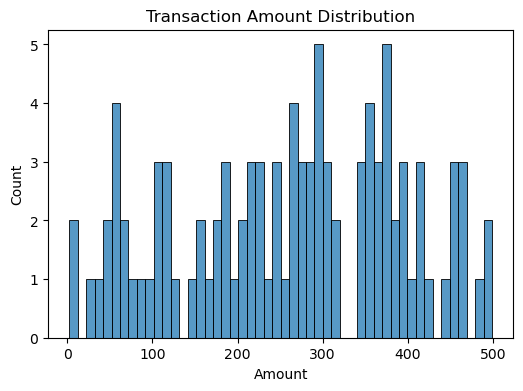

ValueError: Expected n_neighbors <= n_samples,  but n_samples = 2, n_neighbors = 6

In [15]:
# ==========================================================
# AI-Based Credit Card Fraud Detection - FINAL PIPELINE V2
# Robust version (works for small & large datasets)
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings("ignore")

from collections import Counter
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE


# ==========================================================
# 1. LOAD DATASET
# ==========================================================
print("\nLoading Dataset...")
data = pd.read_csv(r"data/creditcard.csv")

print("Dataset Shape:", data.shape)
print("\nClass Distribution:")
print(data['Class'].value_counts())


# ==========================================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================================
plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=data)
plt.title("Class Distribution")
plt.show()

fraud_percentage = (data['Class'].sum()/len(data))*100
print(f"\nFraud Percentage: {fraud_percentage:.4f}%")

plt.figure(figsize=(6,4))
sns.histplot(data["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()


# ==========================================================
# 3. DATA PREPROCESSING
# ==========================================================
X = data.drop("Class", axis=1)
y = data["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ==========================================================
# 🔥 SAFE SMOTE (FIXED)
# ==========================================================
print("\nBefore SMOTE:", Counter(y_train))

fraud_count = Counter(y_train)[1]
k_neighbors = min(5, fraud_count - 1)

if k_neighbors < 1:
    print("⚠ Too few fraud samples — SMOTE skipped")
else:
    smote = SMOTE(k_neighbors=k_neighbors, random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)
    print("After SMOTE:", Counter(y_train))


# ==========================================================
# 4. MODEL TRAINING FUNCTION
# ==========================================================
results = {}

def evaluate_model(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    print(f"\n===== {name} =====")
    print("Accuracy:", acc)
    print("ROC-AUC:", roc)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    results[name] = acc

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

    return model


# ==========================================================
# 5. TRAIN BASE MODELS
# ==========================================================
lr = evaluate_model("Logistic Regression", LogisticRegression(max_iter=1000))
rf = evaluate_model("Random Forest", RandomForestClassifier(n_estimators=200, random_state=42))
xgb = evaluate_model("XGBoost", XGBClassifier(use_label_encoder=False, eval_metric='logloss'))


# ==========================================================
# 6. ROC CURVE
# ==========================================================
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


# ==========================================================
# 7. HYPERPARAMETER TUNING (XGBOOST)
# ==========================================================
print("\nPerforming Hyperparameter Tuning...")

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6],
    "learning_rate": [0.01, 0.1]
}

grid = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    param_grid,
    cv=3,
    scoring="recall",
    n_jobs=-1
)

grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)

final_model = grid.best_estimator_

y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:,1]

print("\n===== FINAL TUNED XGBOOST =====")
print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_final))
print(confusion_matrix(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))


# ==========================================================
# 8. FEATURE IMPORTANCE
# ==========================================================
plt.figure(figsize=(10,6))
importance = final_model.feature_importances_
indices = np.argsort(importance)[-10:]

plt.barh(range(len(indices)), importance[indices])
plt.yticks(range(len(indices)), np.array(X.columns)[indices])
plt.title("Top 10 Important Features")
plt.show()


# ==========================================================
# 9. SAVE MODEL + SCALER
# ==========================================================
pickle.dump(final_model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("\nModel and Scaler saved successfully!")


# ==========================================================
# 10. FINAL SUMMARY
# ==========================================================
best_model_name = max(results, key=results.get)

print("\n===================================")
print("BEST BASE MODEL:", best_model_name)
print("FINAL DEPLOYED MODEL: Tuned XGBoost")
print("PIPELINE COMPLETED SUCCESSFULLY")
print("===================================")